In [37]:
# --- Core Libraries ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import copy
import time
import warnings
warnings.filterwarnings('ignore')
import time
from tqdm.auto import tqdm
import cv2
cv2.setNumThreads(0)
cv2.ocl.setUseOpenCL(False)
# --- PyTorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import transforms
from torchvision import models
# --- Scikit-learn ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# --- Misc ---
from tqdm.notebook import tqdm

# --- Device Configuration ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'    GPU Name : {torch.cuda.get_device_name(0)}')
# print(f'    GPU RAM  : {torch.cuda.get_device_properties(0).total_memory / 1e2**9:.1f} GB')

print(f'PyTorch  : {torch.__version__}')
print('Setup complete!')

Using device: cuda
    GPU Name : Tesla T4
PyTorch  : 2.10.0+cu128
Setup complete!


In [13]:
# ============================================================================
# CELL 2: CONFIGURATION — Hyperparameters & Paths
# ============================================================================

DATASET_NAME = 'handwritten21/3'

# --- Paths ---
PATH_ROOT   = '/kaggle/input/datasets/cnghng0024/handwritten213/sign_data/sign_data/'
TRAIN_DIR   = os.path.join(PATH_ROOT, 'train/')
TEST_DIR    = os.path.join(PATH_ROOT, 'test/')   
TRAIN_CSV   = os.path.join(PATH_ROOT, 'train_data.csv')
TEST_CSV    = os.path.join(PATH_ROOT, 'test_data.csv')
SAVE_PATH   = '/kaggle/working/best_model.pth'

# --- Hyperparameters ---
BATCH_SIZE  = 64
EPOCHS      = 30
LR          = 0.0001
MARGIN      = 1.0      # Margin cho Contrastive Loss
VAL_SPLIT   = 0.2      # 80% train / 20% validation
NUM_WORKERS = 4
PERSISTENT  = False
EMBED_DIM   = 128      # Chieu embedding vector
SEED        = 42

# --- Reproducibility ---
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Kiem tra du lieu ---
assert os.path.exists(TRAIN_CSV), f'Khong tim thay {TRAIN_CSV}'
assert os.path.exists(TEST_CSV),  f'Khong tim thay {TEST_CSV}'
assert os.path.isdir(TRAIN_DIR),  f'Khong tim thay thu muc {TRAIN_DIR}'

print('PATH_ROOT  :', PATH_ROOT)
print('BATCH_SIZE :', BATCH_SIZE)
print('EPOCHS     :', EPOCHS)
print('LR         :', LR)
print('MARGIN     :', MARGIN)
print('Config loaded!')

PATH_ROOT  : /kaggle/input/datasets/cnghng0024/handwritten213/sign_data/sign_data/
BATCH_SIZE : 64
EPOCHS     : 30
LR         : 0.0001
MARGIN     : 1.0
Config loaded!


In [14]:
# ============================================================================
# CELL 3: PIPELINE (ĐÃ FIX SẠCH NHIỄU OTSU - DÙNG CHUNG TRAIN & DEMO)
# ============================================================================

IMG_HEIGHT = 128
IMG_WIDTH = 256

# --- 1. ĐỊNH NGHĨA BỘ TĂNG CƯỜNG (Chỉ dùng cho tập Train) ---
train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(10),              
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.ToTensor(),
    # Elastic Transform cực kỳ hiệu quả với dữ liệu nét chữ
    transforms.ElasticTransform(alpha=25.0, sigma=5.0) 
])

# --- 2. HÀM TIỀN XỬ LÝ (SẠCH NHIỄU TUYỆT ĐỐI - KHÔNG BÓP MÉO) ---
def preprocess_signature(img_path, img_height=IMG_HEIGHT, img_width=IMG_WIDTH):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros((img_height, img_width), dtype=np.uint8)

    # KHỬ NHIỄU MẠNH BẰNG OTSU (Đã sửa)
    blur = cv2.GaussianBlur(img, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Dọn rác li ti
    kernel = np.ones((2, 2), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # Crop phần khoảng trắng thừa xung quanh
    coords = cv2.findNonZero(thresh)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        thresh = thresh[y:y+h, x:x+w]
    else:
        h, w = thresh.shape

    # Tính tỷ lệ thu phóng sao cho vừa khít khung chữ nhật (không bóp méo)
    scale = min(img_height / h, img_width / w)
    new_h, new_w = int(h * scale), int(w * scale)
        
    if new_w == 0 or new_h == 0:
        return np.zeros((img_height, img_width), dtype=np.uint8)

    resized = cv2.resize(thresh, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Tạo nền đen chuẩn 128x256 và dán chữ ký vào giữa (Padding)
    canvas = np.zeros((img_height, img_width), dtype=np.uint8)
    y_offset = (img_height - new_h) // 2
    x_offset = (img_width - new_w) // 2
    canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = resized

    return canvas # Trả về mảng 0-255

# --- 3. DATASET CLASS ---
class SignatureDataset(Dataset):
    def __init__(self, dataframe, img_height=IMG_HEIGHT, img_width=IMG_WIDTH, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.img_height = img_height
        self.img_width = img_width
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        root = row['root_dir']
        
        img_ref_raw = preprocess_signature(os.path.join(root, row['reference_img']), self.img_height, self.img_width)
        img_test_raw = preprocess_signature(os.path.join(root, row['test_img']), self.img_height, self.img_width)

        if self.transform:
            img_ref = self.transform(img_ref_raw)
            img_test = self.transform(img_test_raw)
        else:
            img_ref = torch.FloatTensor(img_ref_raw / 255.0).unsqueeze(0)
            img_test = torch.FloatTensor(img_test_raw / 255.0).unsqueeze(0)

        return img_ref, img_test, torch.FloatTensor([row['label']])

# --- 4. CHIA DỮ LIỆU THEO ĐÚNG CHUẨN DATASET GỐC (Zero-Leakage) ---
# Đọc file CSV
raw_train = pd.read_csv(TRAIN_CSV, header=None, names=['reference_img', 'test_img', 'label'])
raw_train['root_dir'] = TRAIN_DIR 

raw_test = pd.read_csv(TEST_CSV, header=None, names=['reference_img', 'test_img', 'label'])
raw_test['root_dir'] = TEST_DIR   

# Rút trích ID người dùng (Subject) từ ảnh Reference của tập Train
raw_train['subject_id'] = raw_train['reference_img'].apply(lambda x: str(x).split('/')[0])

# Chia file train_data.csv thành 80% Train và 20% Val theo từng nhóm người
unique_train_subjects = raw_train['subject_id'].unique()
train_subj, val_subj = train_test_split(unique_train_subjects, test_size=VAL_SPLIT, random_state=SEED)

train_df = raw_train[raw_train['subject_id'].isin(train_subj)].reset_index(drop=True)
val_df = raw_train[raw_train['subject_id'].isin(val_subj)].reset_index(drop=True)

# Giữ nguyên 100% file test_data.csv làm tập Test chuẩn mực
test_df = raw_test.copy()

print(f"Tổng số người trong tập Train gốc: {len(unique_train_subjects)}")
print(f" -> Chia vào Train set: {len(train_subj)} người")
print(f" -> Chia vào Val set  : {len(val_subj)} người")

# --- 5. KHỞI TẠO DATALOADERS (TỐI ƯU HÓA CHO KAGGLE GPU) ---
train_loader = DataLoader(SignatureDataset(train_df, transform=train_transforms),
                          batch_size=BATCH_SIZE, 
                          shuffle=True, 
                          num_workers=NUM_WORKERS,
                          pin_memory=True,           # Tăng tốc độ copy RAM (CPU) thẳng vào VRAM (GPU)
                          persistent_workers=True)   # Không tắt/bật lại tiến trình CPU sau mỗi Epoch (Tiết kiệm CPU)

val_loader   = DataLoader(SignatureDataset(val_df, transform=None),
                          batch_size=BATCH_SIZE, 
                          shuffle=False, 
                          num_workers=NUM_WORKERS,
                          pin_memory=True,
                          persistent_workers=True)

test_loader  = DataLoader(SignatureDataset(test_df, transform=None),
                          batch_size=BATCH_SIZE, 
                          shuffle=False, 
                          num_workers=NUM_WORKERS,
                          pin_memory=True,
                          persistent_workers=True)

print(f'Pipeline Ready với Data Augmentation (Khung ảnh: {IMG_WIDTH}x{IMG_HEIGHT})!')

Tổng số người trong tập Train gốc: 64
 -> Chia vào Train set: 51 người
 -> Chia vào Val set  : 13 người
Pipeline Ready với Data Augmentation (Khung ảnh: 256x128)!


In [15]:
# ============================================================================
# CELL 4: MODEL DESIGN — ResNet18 Siamese Network
# ============================================================================

class SiameseNetwork(nn.Module):
    """
    Siamese Network sử dụng ResNet18 làm Backbone.
    Input  : img1 (B,1,128,128), img2 (B,1,128,128)
    Output : L2-Normalized embed1 (B,128), embed2 (B,128)
    """
    def __init__(self, embed_dim=EMBED_DIM):
        super(SiameseNetwork, self).__init__()
        
        # Load pre-trained ResNet18
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        for param in resnet.parameters():
            param.requires_grad = False

        # Đổi Conv1 xong thì phải bật đèn xanh cho nó học
        resnet.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        for param in resnet.conv1.parameters():
            param.requires_grad = True

        for param in resnet.layer4[1].parameters():
            param.requires_grad = True
        
        # Lấy toàn bộ backbone trừ layer Fully Connected cuối cùng
        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        
        # Mạng chiếu (Neck) để đưa về 128 chiều
        self.neck = nn.Sequential(
            nn.Flatten(),
            nn.Linear(resnet.fc.in_features, 512),
            nn.BatchNorm1d(512), 
            nn.ReLU(inplace=True),
            nn.Dropout(0.6), # Tăng lên 0.6 để chống "học vẹt" mạnh hơn
            nn.Linear(512, embed_dim)
        )

    def forward_once(self, x):
        x = self.backbone(x)
        x = self.neck(x)
        # BÍ QUYẾT: Chuẩn hóa L2. Kéo tất cả các vector về hình cầu đơn vị.
        # Giúp khoảng cách giới hạn rõ rệt trong[0, 2], phân cụm cực tốt.
        x = F.normalize(x, p=2, dim=1) 
        return x

    def forward(self, img1, img2):
        embed1 = self.forward_once(img1)
        embed2 = self.forward_once(img2)
        return embed1, embed2

# --- Khoi tao model ---
model = SiameseNetwork(embed_dim=EMBED_DIM).to(device)
if torch.cuda.device_count() > 1:
    print(f"Kích hoạt chạy đa GPU trên {torch.cuda.device_count()} con GPUs!")
    model = nn.DataParallel(model)

model = model.to(device)
# --- Thong ke model ---
total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('SiameseNetwork Architecture (ResNet18 Backbone)')
print('=' * 50)
print(f'Total params     : {total_params:,}')
print(f'Trainable params : {trainable:,}')
print('Model created!')

Kích hoạt chạy đa GPU trên 2 con GPUs!
SiameseNetwork Architecture (ResNet18 Backbone)
Total params     : 11,499,584
Trainable params : 5,053,120
Model created!


In [21]:
# ============================================================================
# CELL 5: TRAINING LOOP — Full Implementation with Scheduler
# ============================================================================

# --- 1. ĐỊNH NGHĨA LOSS FUNCTION ---
class ContrastiveLoss(torch.nn.Module):
    def __init__(self, margin=MARGIN):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, embed1, embed2, label):
        distance = F.pairwise_distance(embed1, embed2, keepdim=True)
        loss = (1 - label) * 0.5 * torch.pow(distance, 2) + \
               label * 0.5 * torch.pow(torch.clamp(self.margin - distance, min=0.0), 2)
        return loss.mean()

# --- 2. ĐỊNH NGHĨA CÁC HÀM HỖ TRỢ ---
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, num_batches = 0.0, 0
    pbar = tqdm(loader, desc='  Train', leave=False)
    for img_ref, img_test, label in pbar:
        img_ref, img_test, label = img_ref.to(device), img_test.to(device), label.to(device)

        optimizer.zero_grad()
        embed1, embed2 = model(img_ref, img_test)
        loss = criterion(embed1, embed2, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        num_batches += 1
    return running_loss / num_batches

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, num_batches = 0.0, 0
    with torch.no_grad():
        pbar = tqdm(loader, desc='  Valid', leave=False)
        for img_ref, img_test, label in pbar:
            img_ref, img_test, label = img_ref.to(device), img_test.to(device), label.to(device)
            embed1, embed2 = model(img_ref, img_test)
            loss = criterion(embed1, embed2, label)
            running_loss += loss.item()
            num_batches += 1
    return running_loss / num_batches

# --- 3. KHỞI TẠO CRITERION, OPTIMIZER & SCHEDULER ---
criterion = ContrastiveLoss(margin=MARGIN)
# Chỉ truyền các tham số cần học vào Optimizer
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), 
                         lr=LR, weight_decay=0.05)

# Scheduler: Giảm Learning Rate đi một nửa (factor 0.5) nếu Val_Loss không giảm sau 3 epochs (patience 3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# --- 4. CẤU HÌNH CHẾ ĐỘ CHẠY ---
RETRAIN_FROM_SCRATCH = True

start_epoch = 1
best_val_loss = float('inf')
train_losses, val_losses =[],[]

if not RETRAIN_FROM_SCRATCH and os.path.exists(SAVE_PATH):
    print(f'[*] Tìm thấy checkpoint tại: {SAVE_PATH}')
    checkpoint = torch.load(SAVE_PATH, map_location=device)
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_loss = checkpoint['best_val_loss']
        train_losses = checkpoint.get('train_losses',[])
        val_losses = checkpoint.get('val_losses', [])
        print(f'   [+] Resume thành công từ Epoch {start_epoch}')
    else:
        model.load_state_dict(checkpoint)
        print('   [!] Đã nạp trọng số từ file cũ.')

# --- 5. VÒNG LẶP HUẤN LUYỆN CHÍNH ---
print(f'\nĐang huấn luyện trên: {device}')
print('=' * 60)

for epoch in range(start_epoch, EPOCHS + 1):
    start_time = time.time()

    t_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    v_loss = validate_one_epoch(model, val_loader, criterion, device)
    
    # Bước nhảy Scheduler dựa vào Val_Loss
    scheduler.step(v_loss)

    train_losses.append(t_loss)
    val_losses.append(v_loss)
    elapsed = time.time() - start_time

    # --- ĐOẠN NÀY ĐÃ ĐƯỢC CANH LỀ CHUẨN XÁC NẰM TRONG VÒNG LẶP FOR ---
    save_flag = ''
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        checkpoint_data = {
            'epoch': epoch,
            'model_state_dict': model.module.state_dict() if hasattr(model, 'module') else model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'best_val_loss': best_val_loss,
            'train_losses': train_losses,
            'val_losses': val_losses
        }
        torch.save(checkpoint_data, SAVE_PATH)
        save_flag = ' * BEST MODEL SAVED!'

    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch[{epoch:02d}/{EPOCHS}] LR: {current_lr:.6f} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Time: {elapsed:.1f}s {save_flag}')

print('=' * 60)
print(f'Huấn luyện hoàn tất! Best Val Loss: {best_val_loss:.4f}')


Đang huấn luyện trên: cuda


  Train:   0%|          | 0/279 [00:00<?, ?it/s]

  Valid:   0%|          | 0/84 [00:00<?, ?it/s]

Epoch[01/30] LR: 0.000100 | Train Loss: 0.1483 | Val Loss: 0.1167 | Time: 750.3s  * BEST MODEL SAVED!


  Train:   0%|          | 0/279 [00:00<?, ?it/s]

...

  Valid:   0%|          | 0/84 [00:00<?, ?it/s]

Epoch[04/30] LR: 0.000100 | Train Loss: 0.0472 | Val Loss: 0.1180 | Time: 741.6s 


  Train:   0%|          | 0/279 [00:00<?, ?it/s]

Exception in thread Thread-5 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.12/threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.12/threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 52, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/pin_memory.py", line 28, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/torch/multiprocessing/reductions.py", line 540, in rebuild_storage_fd
    fd = df.detach()
         ^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/resource_s

KeyboardInterrupt: 

Cột trong file của ông đây này: ['068/09_068.png', '068_forg/03_0113068.PNG', '1']
 ĐANG BỐC THĂM NGẪU NHIÊN 2 CẶP ẢNH ĐỂ TEST...
🏆 ĐỘ CHÍNH XÁC (ACCURACY): 80.79%
Tổng số mẫu Test: 5,748 cặp chữ ký
Dự đoán ĐÚNG    : 4,644 cặp
Dự đoán SAI     : 1,104 cặp

--- 1. TEST CẶP CHỮ KÝ THẬT ---


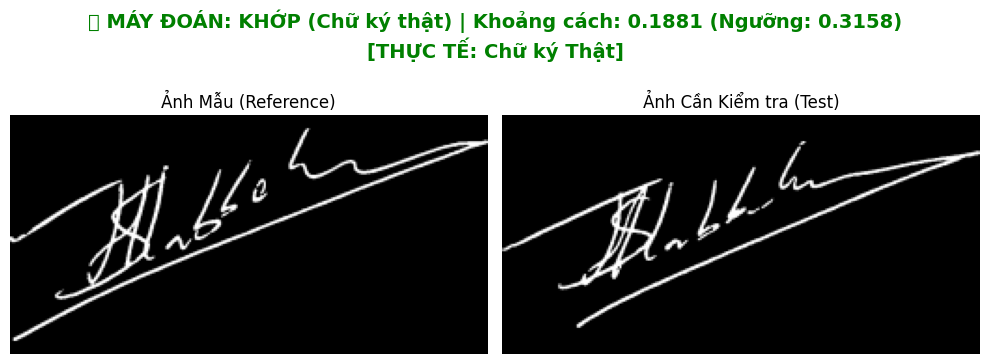


--- 2. TEST CẶP CHỮ KÝ GIẢ MẠO ---


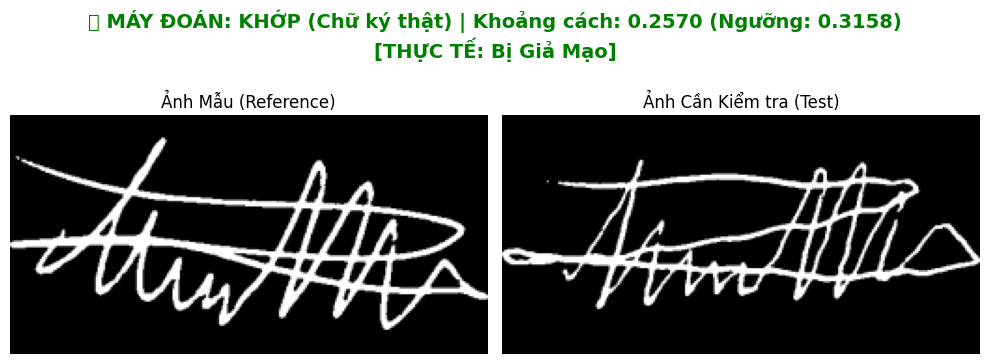


--- 1. TEST CẶP CHỮ KÝ THẬT ---
📁 Ảnh Mẫu : /kaggle/input/datasets/cnghng0024/handwritten213/sign_data/sign_data/test/050/10_050.png
📁 Ảnh Test: /kaggle/input/datasets/cnghng0024/handwritten213/sign_data/sign_data/test/050/05_050.png


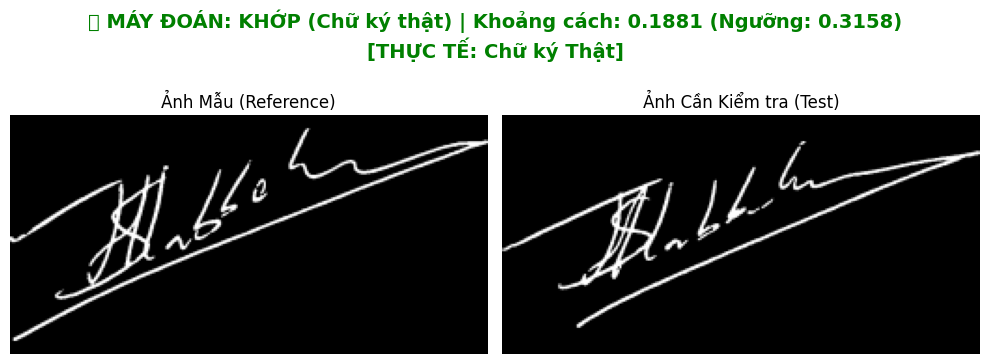


--- 2. TEST CẶP CHỮ KÝ GIẢ MẠO ---
📁 Ảnh Mẫu : /kaggle/input/datasets/cnghng0024/handwritten213/sign_data/sign_data/test/054/09_054.png
📁 Ảnh Test: /kaggle/input/datasets/cnghng0024/handwritten213/sign_data/sign_data/test/054_forg/04_0102054.PNG


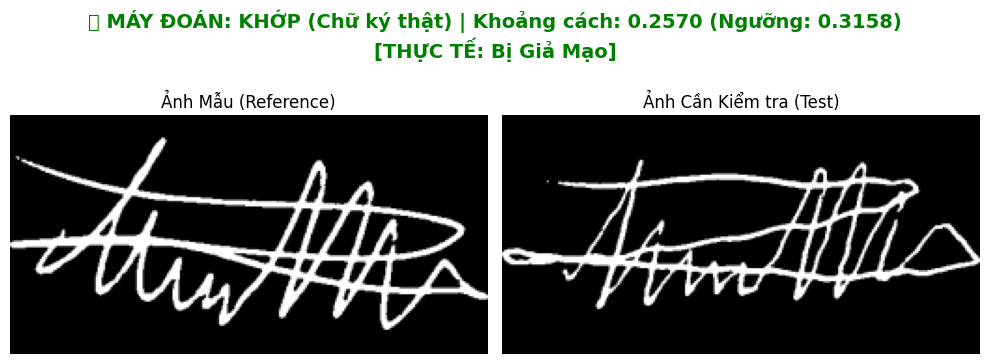

In [50]:
# ============================================================================
# CELL 7: DEMO KIỂM TRA MÔ HÌNH THỰC TẾ (LẤY NGẪU NHIÊN TỪ TẬP TEST)
# ============================================================================
import matplotlib.pyplot as plt
import random

# Lấy Ngưỡng (Threshold) vừa tìm được ở Cell 6
BEST_THRESHOLD = 0.3158 

print("Cột trong file của ông đây này:", df_test.columns.tolist())
print
def visualize_prediction(model, path_img1, path_img2, actual_label, threshold=BEST_THRESHOLD):
    # 1. Tiền xử lý (Dùng hàm đã fix Otsu ở Cell 3)
    img1 = preprocess_signature(path_img1, IMG_HEIGHT, IMG_WIDTH)
    img2 = preprocess_signature(path_img2, IMG_HEIGHT, IMG_WIDTH)
    
    # 2. Chuyển sang Tensor
    t1 = torch.FloatTensor(img1 / 255.0).unsqueeze(0).unsqueeze(0).to(device)
    t2 = torch.FloatTensor(img2 / 255.0).unsqueeze(0).unsqueeze(0).to(device)
    
    # 3. Chạy qua model (Lưu ý: Dùng eval_model đã load ở Cell 6)
    model.eval()
    with torch.no_grad():
        emb1, emb2 = model(t1, t2)
        dist = F.pairwise_distance(emb1, emb2).item()
        
    is_match = dist < threshold
    
    # 4. Trực quan hóa
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].imshow(img1, cmap='gray')
    axes[0].set_title("Ảnh Mẫu (Reference)")
    axes[0].axis('off')
    
    axes[1].imshow(img2, cmap='gray')
    axes[1].set_title("Ảnh Cần Kiểm tra (Test)")
    axes[1].axis('off')
    
    # Đánh giá kết quả dự đoán so với thực tế
    if is_match:
        pred_text = "✅ MÁY ĐOÁN: KHỚP (Chữ ký thật)"
        pred_color = 'green'
    else:
        pred_text = "❌ MÁY ĐOÁN: KHÔNG KHỚP (Giả mạo)"
        pred_color = 'red'
        
    actual_text = "THỰC TẾ: Chữ ký Thật" if actual_label == 0 else "THỰC TẾ: Bị Giả Mạo"
    
    plt.suptitle(f"{pred_text} | Khoảng cách: {dist:.4f} (Ngưỡng: {threshold})\n[{actual_text}]", 
                 color=pred_color, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# ==========================================
# CHẠY THỬ NGHIỆM TỰ ĐỘNG
# ==========================================
print(" ĐANG BỐC THĂM NGẪU NHIÊN 2 CẶP ẢNH ĐỂ TEST...")

# Bốc 1 cặp Thật (Label = 0)
gen_sample = test_df[test_df['label'] == 0].sample(1).iloc[0]
path_ref_gen = os.path.join(gen_sample['root_dir'], gen_sample['reference_img'])
path_test_gen = os.path.join(gen_sample['root_dir'], gen_sample['test_img'])

# Bốc 1 cặp Giả (Label = 1)
forg_sample = test_df[test_df['label'] == 1].sample(1).iloc[0]
path_ref_forg = os.path.join(forg_sample['root_dir'], forg_sample['reference_img'])
path_test_forg = os.path.join(forg_sample['root_dir'], forg_sample['test_img'])

accuracy = accuracy_score(labels, predictions)
print("="*40)
print(f"🏆 ĐỘ CHÍNH XÁC (ACCURACY): {accuracy * 100:.2f}%")
print(f"Tổng số mẫu Test: {len(labels):,} cặp chữ ký")
print(f"Dự đoán ĐÚNG    : {int(accuracy * len(labels)):,} cặp")
print(f"Dự đoán SAI     : {len(labels) - int(accuracy * len(labels)):,} cặp")
print("="*40)

print("\n--- 1. TEST CẶP CHỮ KÝ THẬT ---")
visualize_prediction(eval_model, path_ref_gen, path_test_gen, actual_label=0)

print("\n--- 2. TEST CẶP CHỮ KÝ GIẢ MẠO ---")
visualize_prediction(eval_model, path_ref_forg, path_test_forg, actual_label=1)

# ==========================================
# KIỂM TRA & IN ĐƯỜNG DẪN TỪNG CẶP
# ==========================================
print("\n" + "="*60)
print("--- 1. TEST CẶP CHỮ KÝ THẬT ---")
print(f"📁 Ảnh Mẫu : {path_ref_gen}")
print(f"📁 Ảnh Test: {path_test_gen}")
print("="*60)
visualize_prediction(eval_model, path_ref_gen, path_test_gen, actual_label=0)

print("\n" + "="*60)
print("--- 2. TEST CẶP CHỮ KÝ GIẢ MẠO ---")
print(f"📁 Ảnh Mẫu : {path_ref_forg}")
print(f"📁 Ảnh Test: {path_test_forg}")
print("="*60)
visualize_prediction(eval_model, path_ref_forg, path_test_forg, actual_label=1)

🔍 Testing:   0%|          | 0/5748 [00:00<?, ?it/s]


📊 KẾT QUẢ:
🔹 Accuracy: 80.83%
🔹 Precision: 81.94%
🔹 Recall: 80.78%
🔹 F1: 81.35%


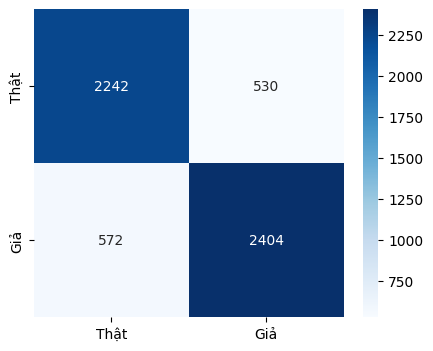

In [44]:
import pandas as pd
import numpy as np
import os
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
# 1. Cấu hình nhanh
BASE_DIR = "/kaggle/input/datasets/cnghng0024/handwritten213/sign_data/test/"
TEST_CSV = "/kaggle/input/datasets/cnghng0024/handwritten213/sign_data/test_data.csv"

def evaluate_full_test_set(model, threshold=BEST_THRESHOLD):
    # Nạp CSV không header và đặt tên cột
    df = pd.read_csv(TEST_CSV, header=None, names=['ref', 'test', 'label'])
    y_true, y_pred = [], []

    model.eval()
    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df), desc="🔍 Testing"):
            try:
                # Nối đường dẫn tuyệt đối
                p1 = os.path.join(BASE_DIR, row['ref'])
                p2 = os.path.join(BASE_DIR, row['test'])
                
                # Tiền xử lý & Dự đoán
                t1 = torch.FloatTensor(preprocess_signature(p1, IMG_HEIGHT, IMG_WIDTH)/255).unsqueeze(0).unsqueeze(0).to(device)
                t2 = torch.FloatTensor(preprocess_signature(p2, IMG_HEIGHT, IMG_WIDTH)/255).unsqueeze(0).unsqueeze(0).to(device)
                
                emb1, emb2 = model(t1, t2)
                dist = F.pairwise_distance(emb1, emb2).item()
                
                y_true.append(int(row['label']))
                y_pred.append(1 if dist > threshold else 0)
            except: continue

    # Tính toán nhanh
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }

    print("\n📊 KẾT QUẢ:")
    for k, v in metrics.items(): print(f"🔹 {k}: {v*100:.2f}%")
    
    # Vẽ Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Thật','Giả'], yticklabels=['Thật','Giả'])
    plt.show()
    return y_true, y_pred

# THỰC THI
y_true, y_pred = evaluate_full_test_set(eval_model)

In [49]:
import random
import cv2
import matplotlib.pyplot as plt

# Cấu hình số lượng mẫu muốn xem
num_to_show = 5 
threshold = BEST_THRESHOLD # Đảm bảo biến này đã có từ cell trước

if 'errors' in locals() and len(errors) > 0:
    print(f"🖼️ ĐANG HIỂN THỊ {min(num_to_show, len(errors))} TRƯỜNG HỢP SAI NGẪU NHIÊN:")
    
    # Bốc ngẫu nhiên vài ca sai
    samples = random.sample(errors, min(num_to_show, len(errors)))
    
    for i, case in enumerate(samples):
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        
        # Đọc ảnh (BGR -> RGB)
        img1 = cv2.cvtColor(cv2.imread(case['p1']), cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(cv2.imread(case['p2']), cv2.COLOR_BGR2RGB)
        
        axes[0].imshow(img1)
        axes[0].set_title("Ảnh Gốc (Ref)")
        axes[0].axis('off')
        
        axes[1].imshow(img2)
        axes[1].set_title("Ảnh Kiểm tra (Test)")
        axes[1].axis('off')
        
        label_map = {0: "Thật (Khớp)", 1: "Giả (Không khớp)"}
        
        # Màu đỏ cho nổi bật vì đây là các ca dự đoán SAI
        plt.suptitle(f"LỖI #{i+1}: Thực tế: {label_map[case['actual']]} | Máy đoán: {label_map[case['pred']]}\nDistance: {case['dist']:.4f} (Threshold: {threshold})", 
                     color='red', fontsize=12, fontweight='bold', y=1.15)
        
        plt.tight_layout()
        plt.show()
else:
    print("🚀 Tuyệt vời! Không tìm thấy trường hợp sai nào hoặc chưa chạy Cell 8.")

🚀 Tuyệt vời! Không tìm thấy trường hợp sai nào hoặc chưa chạy Cell 8.
